# Importing Liberaries

In [1]:
import numpy as np
import os
import json
import joblib
import matplotlib.pyplot as plt

# Loading Data

## identify pathes

In [2]:
BASE_PATH = "../Data/"
DATA_PATH = os.path.join(BASE_PATH, "swat_preprocessed")
MODEL_PATH = os.path.join(BASE_PATH, "models")

os.makedirs(MODEL_PATH, exist_ok=True)

## load data

In [3]:
X_train = np.load(os.path.join(DATA_PATH, "X_train.npy"))



In [4]:
X_val = np.load(os.path.join(DATA_PATH, "X_val.npy"))
X_test = np.load(os.path.join(DATA_PATH, "X_test.npy"))

y_test = np.load(os.path.join(DATA_PATH, "y_test.npy"))

# modeling

## Inspect data shape

In [5]:
def flatten_features(array):
    if array.ndim == 3:
        return array.reshape(array.shape[0], -1)
    return array

print("X_train shape:", X_train.shape)
print("X_val shape:", X_val.shape)
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)
print("y_test values:", np.unique(y_test, return_counts=True))

X_train shape: (1245136, 12, 47)
X_val shape: (69163, 12, 47)
X_test shape: (120184, 12, 47)
y_test shape: (120184,)
y_test values: (array([0., 1.]), array([69164, 51020]))


## Train Isolation Forest

Flattened X_train shape: (1245136, 564)
Flattened X_test shape: (120184, 564)
Confusion matrix:
 [[43769 25395]
 [11089 39931]]

Classification report:
               precision    recall  f1-score   support

           0     0.7979    0.6328    0.7058     69164
           1     0.6113    0.7827    0.6864     51020

    accuracy                         0.6964    120184
   macro avg     0.7046    0.7077    0.6961    120184
weighted avg     0.7186    0.6964    0.6976    120184



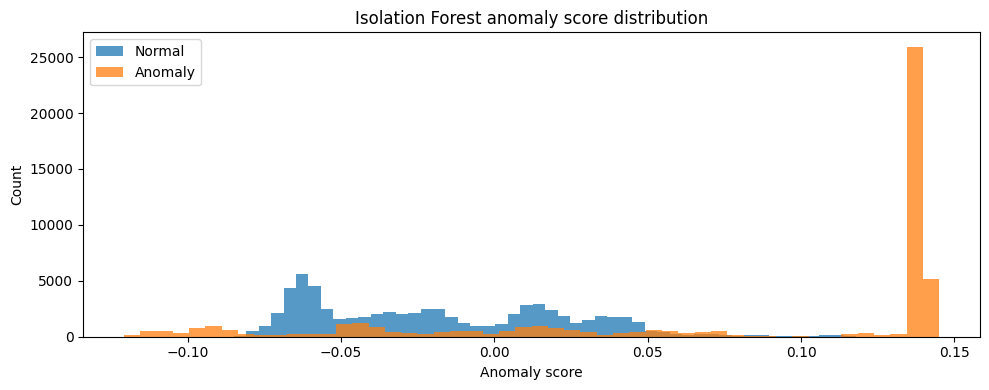

Saved model to: ../Data/models\isolation_forest_model.joblib


In [6]:
from sklearn.ensemble import IsolationForest
from sklearn.metrics import classification_report, confusion_matrix

X_train_flat = flatten_features(X_train)
X_test_flat = flatten_features(X_test)
y_test_binary = (np.asarray(y_test).ravel() != 0).astype(int)

iso_forest = IsolationForest(
    n_estimators=200,
    contamination=0.05,
    random_state=42,
    n_jobs=-1,
)
iso_forest.fit(X_train_flat)

raw_predictions = iso_forest.predict(X_test_flat)
y_pred = (raw_predictions == -1).astype(int)

cm = confusion_matrix(y_test_binary, y_pred)
report = classification_report(y_test_binary, y_pred, digits=4, zero_division=0)

print("Flattened X_train shape:", X_train_flat.shape)
print("Flattened X_test shape:", X_test_flat.shape)
print("Confusion matrix:\n", cm)
print("\nClassification report:\n", report)

anomaly_scores = -iso_forest.decision_function(X_test_flat)

plt.figure(figsize=(10, 4))
plt.hist(anomaly_scores[y_test_binary == 0], bins=50, alpha=0.75, label="Normal")
plt.hist(anomaly_scores[y_test_binary == 1], bins=50, alpha=0.75, label="Anomaly")
plt.title("Isolation Forest anomaly score distribution")
plt.xlabel("Anomaly score")
plt.ylabel("Count")
plt.legend()
plt.tight_layout()
plt.show()

joblib.dump(iso_forest, os.path.join(MODEL_PATH, "isolation_forest_model.joblib"))
print("Saved model to:", os.path.join(MODEL_PATH, "isolation_forest_model.joblib"))

## Contamination Sweep

In [7]:
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score

contamination_grid = [0.01, 0.03, 0.05, 0.08, 0.10]
comparison_rows = []

for contamination in contamination_grid:
    candidate_model = IsolationForest(
        n_estimators=200,
        contamination=contamination,
        random_state=42,
        n_jobs=-1,
    )
    candidate_model.fit(X_train_flat)
    candidate_predictions = (candidate_model.predict(X_test_flat) == -1).astype(int)

    comparison_rows.append(
        {
            "contamination": contamination,
            "accuracy": accuracy_score(y_test_binary, candidate_predictions),
            "precision": precision_score(y_test_binary, candidate_predictions, zero_division=0),
            "recall": recall_score(y_test_binary, candidate_predictions, zero_division=0),
            "f1": f1_score(y_test_binary, candidate_predictions, zero_division=0),
        }
    )

best_row = max(comparison_rows, key=lambda row: row["f1"])
best_contamination = best_row["contamination"]

print("Contamination sweep (ranked by F1):")
for row in sorted(comparison_rows, key=lambda value: value["f1"], reverse=True):
    print(
        f"  contamination={row['contamination']:.2f} | accuracy={row['accuracy']:.4f} | "
        f"precision={row['precision']:.4f} | recall={row['recall']:.4f} | f1={row['f1']:.4f}"
    )

print("\nBest contamination:", best_contamination)

iso_forest = IsolationForest(
    n_estimators=200,
    contamination=best_contamination,
    random_state=42,
    n_jobs=-1,
)
iso_forest.fit(X_train_flat)

raw_predictions = iso_forest.predict(X_test_flat)
y_pred = (raw_predictions == -1).astype(int)

cm = confusion_matrix(y_test_binary, y_pred)
report = classification_report(y_test_binary, y_pred, digits=4, zero_division=0)
anomaly_scores = -iso_forest.decision_function(X_test_flat)

print("\nTuned confusion matrix:\n", cm)
print("\nTuned classification report:\n", report)

joblib.dump(iso_forest, os.path.join(MODEL_PATH, "isolation_forest_tuned.joblib"))
print("Saved tuned model to:", os.path.join(MODEL_PATH, "isolation_forest_tuned.joblib"))

Contamination sweep (ranked by F1):
  contamination=0.01 | accuracy=0.8137 | precision=0.8365 | recall=0.6974 | f1=0.7606
  contamination=0.03 | accuracy=0.7356 | precision=0.6674 | recall=0.7518 | f1=0.7071
  contamination=0.05 | accuracy=0.6964 | precision=0.6113 | recall=0.7827 | f1=0.6864
  contamination=0.08 | accuracy=0.6630 | precision=0.5730 | recall=0.8094 | f1=0.6710
  contamination=0.10 | accuracy=0.6073 | precision=0.5239 | recall=0.8237 | f1=0.6404

Best contamination: 0.01

Tuned confusion matrix:
 [[62211  6953]
 [15440 35580]]

Tuned classification report:
               precision    recall  f1-score   support

           0     0.8012    0.8995    0.8475     69164
           1     0.8365    0.6974    0.7606     51020

    accuracy                         0.8137    120184
   macro avg     0.8188    0.7984    0.8041    120184
weighted avg     0.8162    0.8137    0.8106    120184

Saved tuned model to: ../Data/models\isolation_forest_tuned.joblib


## Confusion Matrix Heatmap

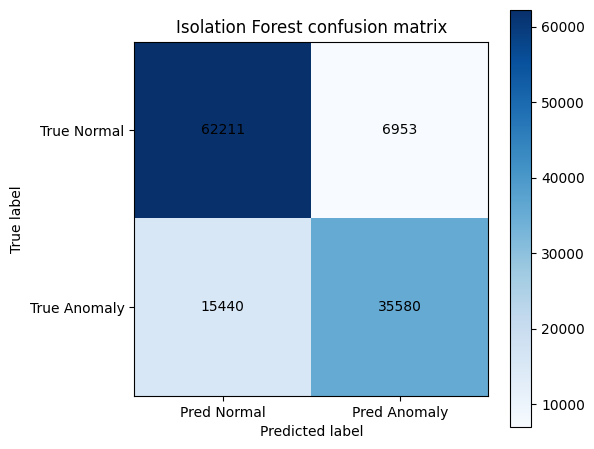

In [8]:
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cm, cmap="Blues")

for row_index in range(cm.shape[0]):
    for column_index in range(cm.shape[1]):
        ax.text(column_index, row_index, f"{cm[row_index, column_index]}", ha="center", va="center", color="black")

ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(["Pred Normal", "Pred Anomaly"])
ax.set_yticklabels(["True Normal", "True Anomaly"])
ax.set_xlabel("Predicted label")
ax.set_ylabel("True label")
ax.set_title("Isolation Forest confusion matrix")
fig.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()

## Results and Interpretation

- The input tensors were flattened from shape `(n_samples, 12, 47)` to `(n_samples, 564)` before training.
- The Isolation Forest model was trained with `n_estimators=200` and `contamination=0.05`.
- Test accuracy was about `0.6964` with anomaly recall of `0.7827` and normal recall of `0.6328`.
- The trained model is saved to `../Data/models/isolation_forest_model.joblib`.

The histogram below shows the anomaly-score separation between normal and anomalous samples.